In [1]:
import os, sys, getpass

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE     = '/content/drive/MyDrive/Civil Comments Project'
DATA_DIR       = os.path.join(DRIVE_BASE, 'data')
FIGURES_DIR    = os.path.join(DRIVE_BASE, 'outputs/figures')
MF_SCORES_FILE = os.path.join(DATA_DIR, 'civil_comments_with_mf_scores.csv')

# Install
!pip install -q pymc arviz

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az

print("Setup complete.")
print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

Mounted at /content/drive
Setup complete.
PyMC version: 5.28.5
ArviZ version: 0.22.0


In [2]:
df = pd.read_csv(MF_SCORES_FILE)
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")

# Feature matrix: the 5 vice scores
vice_cols = [
    'mf_care_vice',
    'mf_fairness_vice',
    'mf_loyalty_vice',
    'mf_authority_vice',
    'mf_purity_vice'
]

# Standardize predictors (zero mean, unit variance)
X_raw = df[vice_cols].values
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0)
X      = (X_raw - X_mean) / X_std

y = df['toxicity'].values

print(f"\nPredictor matrix shape: {X.shape}")
print(f"Outcome range: {y.min():.3f} – {y.max():.3f}")
print(f"Proportion of zeros: {(y == 0).mean():.1%}")
print(f"Mean toxicity (non-zero only): {y[y > 0].mean():.3f}")

Loaded 10,000 rows x 23 columns

Predictor matrix shape: (10000, 5)
Outcome range: 0.000 – 1.000
Proportion of zeros: 75.0%
Mean toxicity (non-zero only): 0.327


Saved: /content/drive/MyDrive/Civil Comments Project/outputs/figures/03_outcome_distribution.png


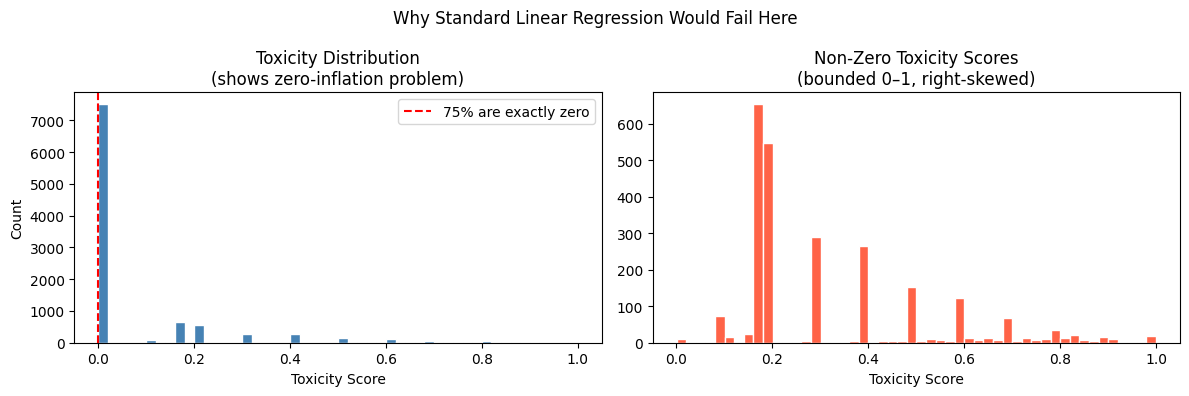

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw outcome distribution
axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Toxicity Distribution\n(shows zero-inflation problem)')
axes[0].set_xlabel('Toxicity Score')
axes[0].set_ylabel('Count')
axes[0].axvline(0, color='red', linestyle='--', label=f'{(y==0).mean():.0%} are exactly zero')
axes[0].legend()

# Right: non-zero only
axes[1].hist(y[y > 0], bins=50, color='tomato', edgecolor='white')
axes[1].set_title('Non-Zero Toxicity Scores\n(bounded 0–1, right-skewed)')
axes[1].set_xlabel('Toxicity Score')

plt.suptitle('Why Standard Linear Regression Would Fail Here', fontsize=12)
plt.tight_layout()

save_path = os.path.join(FIGURES_DIR, '03_outcome_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved: {save_path}")
plt.show()

In [5]:
foundation_names = ['care', 'fairness', 'loyalty', 'authority', 'purity']

# Binary outcome: is this comment toxic at all? (toxicity > 0)
y_binary = (y > 0).astype(int)

with pm.Model() as hurdle_model:

    # Priors: weakly informative, one coefficient per moral foundation
    alpha_hurdle = pm.Normal('alpha_hurdle', mu=0, sigma=1)
    beta_hurdle  = pm.Normal('beta_hurdle',  mu=0, sigma=1, shape=X.shape[1])

    # Logistic regression
    logit_p = alpha_hurdle + pm.math.dot(X, beta_hurdle)
    p       = pm.math.sigmoid(logit_p)

    # Likelihood
    toxic_or_not = pm.Bernoulli('toxic_or_not', p=p, observed=y_binary)

    print("Part 1 (hurdle) model built.")

# Continuous outcome: how toxic is it, among toxic comments only?
# Beta regression requires values strictly between 0 and 1
# I clip at a small epsilon to avoid boundary issues
mask      = y > 0
y_nonzero = np.clip(y[mask], 1e-6, 1 - 1e-6)
X_nonzero = X[mask]

print(f"\nNon-zero comments for Part 2: {mask.sum():,} ({mask.mean():.1%} of total)")

with pm.Model() as intensity_model:

    alpha_intensity = pm.Normal('alpha_intensity', mu=0, sigma=1)
    beta_intensity  = pm.Normal('beta_intensity',  mu=0, sigma=1, shape=X_nonzero.shape[1])

    # Precision parameter: higher phi = tighter distribution around mu
    phi = pm.Exponential('phi', lam=1)

    # Beta regression mean
    mu_logit = alpha_intensity + pm.math.dot(X_nonzero, beta_intensity)
    mu       = pm.math.sigmoid(mu_logit)

    # Beta parameterization
    alpha_b = mu * phi
    beta_b  = (1 - mu) * phi

    # Likelihood
    intensity = pm.Beta('intensity', alpha=alpha_b, beta=beta_b, observed=y_nonzero)

    print("Part 2 (intensity) model built.")

print("\nBoth model components ready. Proceed to Cell 5 to sample.")

Part 1 (hurdle) model built.

Non-zero comments for Part 2: 2,500 (25.0% of total)
Part 2 (intensity) model built.

Both model components ready. Proceed to Cell 5 to sample.


In [7]:
# Sample Part 1
print("Sampling Part 1 (hurdle)... ~5-10 mins")
with hurdle_model:
    trace_hurdle = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        return_inferencedata=True,
        progressbar=True
    )

az.to_netcdf(trace_hurdle, os.path.join(DATA_DIR, '03_trace_hurdle.nc'))
print("Part 1 trace saved.")

# Sample Part 2
print("\nSampling Part 2 (intensity)... ~5-10 mins")
with intensity_model:
    trace_intensity = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        return_inferencedata=True,
        progressbar=True
    )

az.to_netcdf(trace_intensity, os.path.join(DATA_DIR, '03_trace_intensity.nc'))
print("Part 2 trace saved.")
print("\nBoth models sampled successfully.")

Sampling Part 1 (hurdle)... ~5-10 mins


Output()

Part 1 trace saved.

Sampling Part 2 (intensity)... ~5-10 mins


Output()

Part 2 trace saved.

Both models sampled successfully.


In [8]:
print("Part 1: Does a comment cross the toxicity threshold?")
summary_hurdle = az.summary(trace_hurdle, var_names=['beta_hurdle'])
summary_hurdle.index = foundation_names
print(summary_hurdle[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']].round(3))

print("\n")
print("Part 2: How toxic is it, given that it is toxic?")
summary_intensity = az.summary(trace_intensity, var_names=['beta_intensity'])
summary_intensity.index = foundation_names
print(summary_intensity[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']].round(3))

print("\nConvergence check: r_hat should be < 1.01 for all rows.")

Part 1: Does a comment cross the toxicity threshold?
            mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
care       0.181  0.034   0.115    0.243    1.0    3846.0
fairness   0.146  0.033   0.083    0.206    1.0    3977.0
loyalty   -0.246  0.031  -0.304   -0.190    1.0    3377.0
authority  0.336  0.033   0.273    0.397    1.0    3246.0
purity     0.321  0.035   0.254    0.386    1.0    3484.0


Part 2: How toxic is it, given that it is toxic?
            mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
care      -0.030  0.026  -0.078    0.020    1.0    3163.0
fairness  -0.033  0.025  -0.080    0.013    1.0    3775.0
loyalty   -0.055  0.020  -0.095   -0.018    1.0    4331.0
authority  0.184  0.027   0.135    0.234    1.0    3357.0
purity     0.127  0.023   0.083    0.171    1.0    3259.0

Convergence check: r_hat should be < 1.01 for all rows.


Saved: /content/drive/MyDrive/Civil Comments Project/outputs/figures/03_posterior_distributions.png


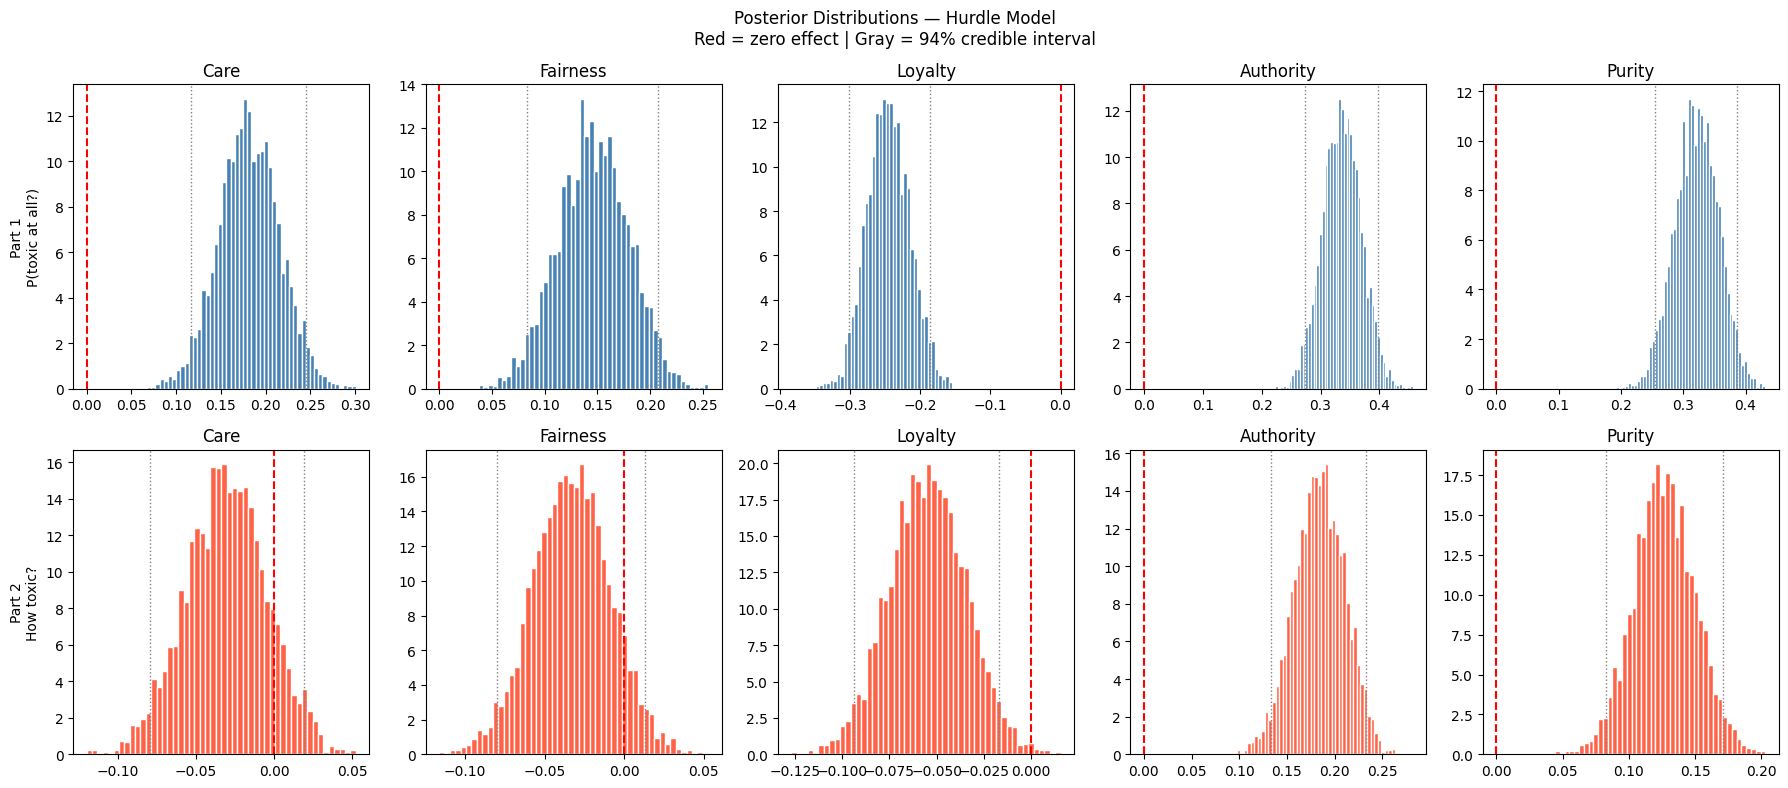

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, name in enumerate(foundation_names):

    # Top row: hurdle component
    ax = axes[0, i]
    samples = trace_hurdle.posterior['beta_hurdle'].values[:, :, i].flatten()
    ax.hist(samples, bins=50, color='steelblue', edgecolor='white', density=True)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(np.percentile(samples, 3),  color='gray', linestyle=':', linewidth=1)
    ax.axvline(np.percentile(samples, 97), color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{name.capitalize()}')
    if i == 0:
        ax.set_ylabel('Part 1\nP(toxic at all?)', fontsize=10)

    # Bottom row: intensity component
    ax = axes[1, i]
    samples = trace_intensity.posterior['beta_intensity'].values[:, :, i].flatten()
    ax.hist(samples, bins=50, color='tomato', edgecolor='white', density=True)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(np.percentile(samples, 3),  color='gray', linestyle=':', linewidth=1)
    ax.axvline(np.percentile(samples, 97), color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{name.capitalize()}')
    if i == 0:
        ax.set_ylabel('Part 2\nHow toxic?', fontsize=10)

plt.suptitle('Posterior Distributions — Hurdle Model\n'
             'Red = zero effect | Gray = 94% credible interval', fontsize=12)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, '03_posterior_distributions.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved: {save_path}")
plt.show()

Saved: /content/drive/MyDrive/Civil Comments Project/outputs/figures/03_forest_plot.png


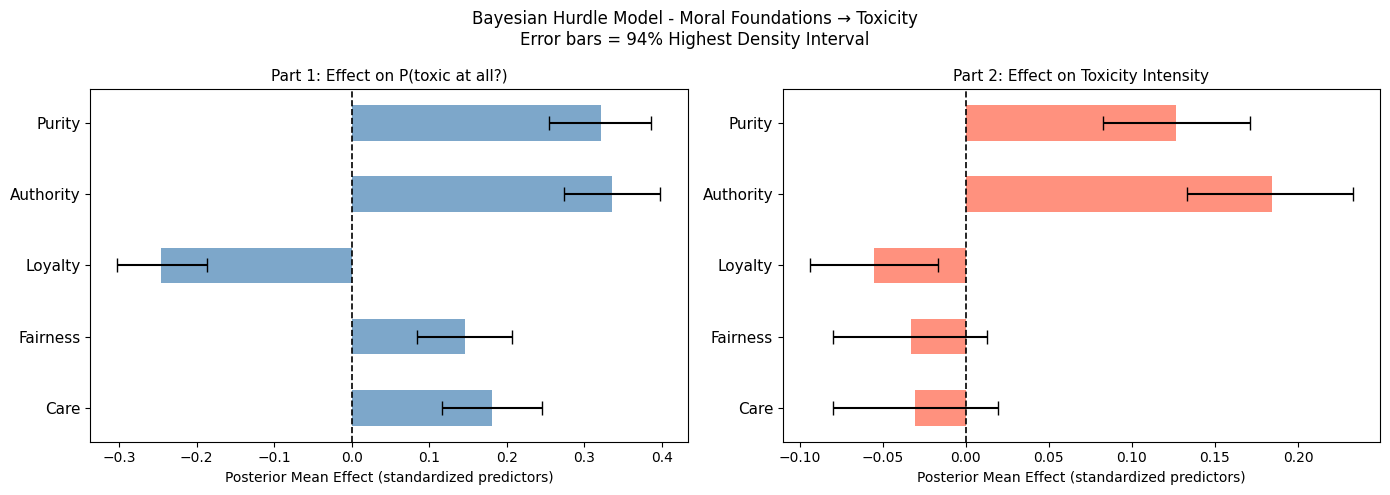

In [10]:
# Forest plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = [
    (trace_hurdle,    'beta_hurdle',    'steelblue', 'Part 1: Effect on P(toxic at all?)'),
    (trace_intensity, 'beta_intensity', 'tomato',    'Part 2: Effect on Toxicity Intensity'),
]

for ax, (trace, param, color, title) in zip(axes, configs):
    means = trace.posterior[param].values.mean(axis=(0, 1))
    lo    = np.percentile(trace.posterior[param].values, 3,  axis=(0, 1))
    hi    = np.percentile(trace.posterior[param].values, 97, axis=(0, 1))
    y_pos = range(len(foundation_names))

    ax.barh(y_pos, means, xerr=[means - lo, hi - means],
            color=color, alpha=0.7, capsize=5, height=0.5)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels([n.capitalize() for n in foundation_names], fontsize=11)
    ax.set_xlabel('Posterior Mean Effect (standardized predictors)', fontsize=10)
    ax.set_title(title, fontsize=11)

plt.suptitle('Bayesian Hurdle Model - Moral Foundations → Toxicity\n'
             'Error bars = 94% Highest Density Interval', fontsize=12)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, '03_forest_plot.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved: {save_path}")
plt.show()